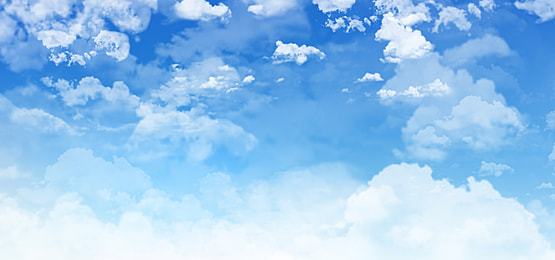

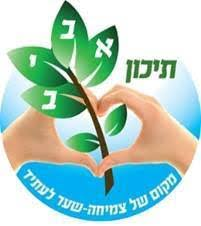

# Forecasting the weather level


---


# The purpose of the study
The purpose of my research is to get data on a certain day and predict the level of the weather according to an index called "type" within which there are 4 different types of definitions of the weather.

### **General information about the project and the dataframe**

Dataframe link: https://www.kaggle.com/datasets/thedevastator/weather-anomalies-in-the-united-states

The dataframe was taken from the site **"kaggle"**

The dataframe was created by someone called **"The Devastator"**

The time range for collection is from **1964-2013**

the dataframe has only **one** version

Last updated date was **2 years** ago

There are about **3,196,831** rows in the dataframe

There are about 10 columns

**"index"** the number of the row

**"date_str"** The date of the weather anomaly.

**"degrees_from_mean"** The number of degrees that the temperature was above or below the monthly mean temperature. (can be used for feature to classify)

**"id"** id

**"longitude"** The longitude of the weather station where the anomaly was recorded. (can be used for feature to classify)

**"latitude"** The latitude of the weather station where the anomaly was recorded. (can be used for feature to classify)

**"max_temp"** The maximum temperature recorded at the weather station on the date of the anomaly. (can be used for feature to classify)

**"min_temp"** The minimum temperature recorded at the weather station on the date of the anomaly. (can be used for feature to classify)

**"station_name"** The name of the weather station where the anomaly was recorded.

**"type"** The type of anomaly, either high or low temperature. (can be used for regression)

target - type

feature to classify - degrees_from_mean, longitude, latitude, max_temp, min_temp

**It is important to note that degrees are measured in Fahrenheit**

In [ ]:
import numpy as np
import scipy.stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score,precision_score,classification_report
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from matplotlib import rcParams
from sklearn.preprocessing import MinMaxScaler,StandardScaler,MaxAbsScaler,RobustScaler,QuantileTransformer,PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import datasets
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import Normalizer
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import Markdown as md
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DATA/weather-anomalies-1964-2013.csv').dropna()

In [ ]:
df

,index,date_str,degrees_from_mean,id,longitude,latitude,max_temp,min_temp,station_name,type,serialid
0,0,1977-02-19,8.61,USC00103882,-113.5472,43.7186,10.0,-12.8,GROUSE,Weak Hot,1
1,1,1977-02-19,10.74,USC00053951,-107.1097,37.7717,11.1,-8.9,HERMIT 7 ESE,Weak Hot,2
2,2,1977-02-19,20.46,USC00040379,-119.5128,37.0919,25.6,12.8,AUBERRY 2 NW,Strong Hot,3
3,3,1977-02-19,8.60,USC00020808,-109.7517,33.4783,20.0,-3.9,BLACK RIVER PUMPS,Weak Hot,4
4,4,1977-02-19,10.30,USC00042598,-115.4508,33.8089,30.6,13.9,EAGLE MTN,Weak Hot,5
...,...,...,...,...,...,...,...,...,...,...,...
3196827,3196827,1993-02-28,-14.38,USC00456768,-119.7581,46.2014,-6.1,-8.3,PROSSER,Weak Cold,3196828
3196828,3196828,1993-02-28,-8.63,USC00350897,-121.9519,45.6361,1.7,-6.7,BONNEVILLE DAM,Weak Cold,3196829
3196829,3196829,1993-02-28,-11.80,USC00358173,-120.7897,42.9592,0.0,-15.0,SUMMER LAKE 1 S,Weak Cold,3196830
3196830,3196830,1993-02-28,-3.41,RQC00663431,-66.6667,18.3361,27.2,13.9,DOS BOCAS,Weak Cold,3196831


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3196832 entries, 0 to 3196831
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   index              int64  
 1   date_str           object 
 2   degrees_from_mean  float64
 3   id                 object 
 4   longitude          float64
 5   latitude           float64
 6   max_temp           float64
 7   min_temp           float64
 8   station_name       object 
 9   type               object 
 10  serialid           int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 268.3+ MB


---
using only 500K datas


In [ ]:
df_sample = df.sample(n=500000, random_state=1)

check if there are any missing values

In [ ]:
df_sample

,index,date_str,id,latitude,max_temp,min_temp,station_name,serialid
2299023,2299023,1996-07-11,USW00093986,34.9894,26.1,18.3,HOBART MUNI AP,2299024
3124038,3124038,1990-07-04,USC00131533,40.7244,37.8,23.9,CLARINDA,3124039
1896869,1896869,1997-02-26,USC00429136,37.3522,21.1,0.0,VEYO PWR HOUSE,1896870
2167488,2167488,1992-04-02,USC00413329,30.2392,11.1,6.1,FREDERICKSBURG,2167489
2775266,2775266,2010-07-19,USW00012835,26.5850,35.0,26.1,FT MYERS PAGE FLD AP,2775267
...,...,...,...,...,...,...,...,...
784381,784381,1967-03-31,USC00237578,39.6361,25.0,14.4,SAVERTON LOCK AND DAM 22,784382
282737,282737,1981-11-04,USC00106877,42.6283,20.0,-2.8,PAUL 1ENE,282738
968243,968243,2013-09-05,USC00391294,45.5489,33.3,16.7,CAMP CROOK,968244
2414875,2414875,1985-09-20,USC00253630,42.6167,12.8,6.1,HARTINGTON,2414876


<Axes: xlabel='degrees_from_mean'>

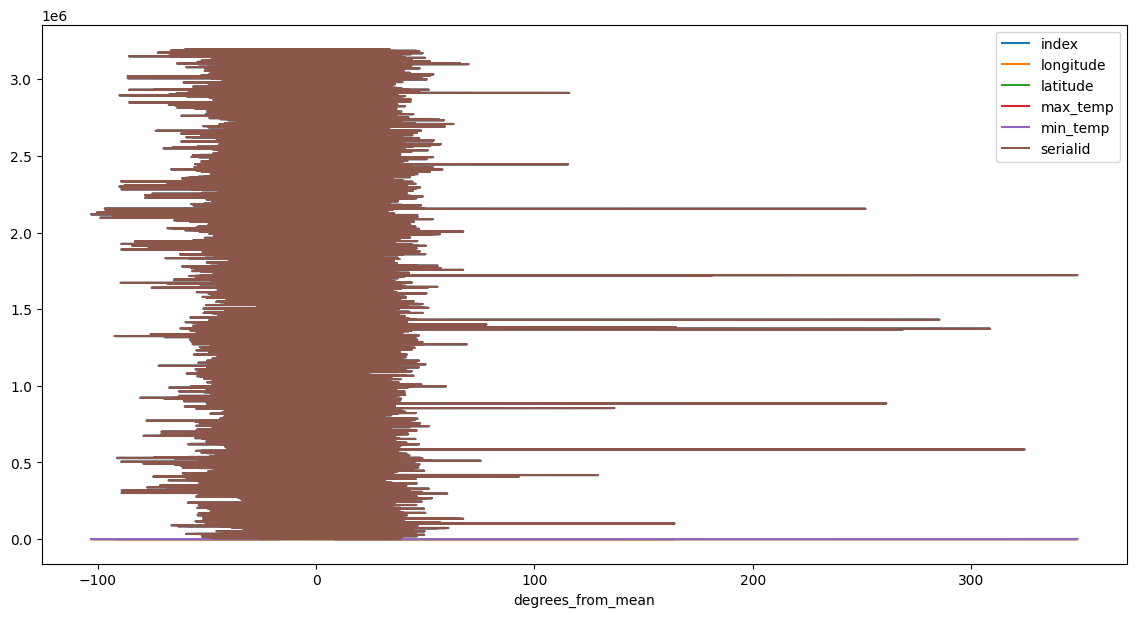

In [ ]:
df.plot("degrees_from_mean", legend=True, figsize=(14,7))

In [ ]:
import folium
import geopy.distance

# Assume `df` is a DataFrame with the correct column names

map = folium.Map(location=[36.1667, -86.7833], zoom_start=12, titles="type")

# Use the correct column name "Station"
for lat, lng, Station in zip(df.latitude, df.longitude, df.Station):
    folium.Marker(
        location=[lat, lng],
        icon=folium.Icon(color="red", icon="type"),
        popup=Station
    ).add_to(map)

display(map)

AttributeError: 'DataFrame' object has no attribute 'Station'

In [ ]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 2299023 to 2350439
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   index         500000 non-null  int64  
 1   date_str      500000 non-null  object 
 2   id            500000 non-null  object 
 3   latitude      500000 non-null  float64
 4   max_temp      500000 non-null  float64
 5   min_temp      500000 non-null  float64
 6   station_name  500000 non-null  object 
 7   serialid      500000 non-null  int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 34.3+ MB


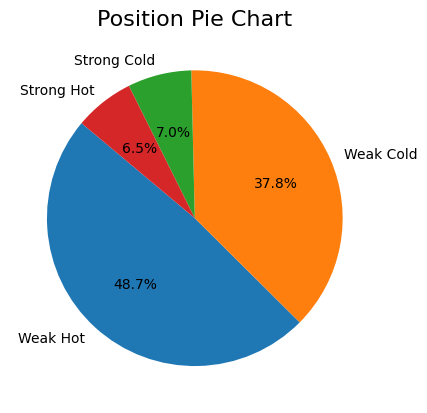

In [ ]:
sizes = df['type'].value_counts()
labels = sizes.index
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab10.colors)
plt.title("Position Pie Chart",fontsize = 16);

In [ ]:
print(df_sample.describe())

              index  degrees_from_mean      longitude       latitude  \
count  5.000000e+05      500000.000000  500000.000000  500000.000000   
mean   1.599646e+06          -0.229833     -97.817329      39.284458   
std    9.223552e+05          14.628720      17.291339       6.426196   
min    1.200000e+01         -94.000000    -170.222200      13.483600   
25%    8.022468e+05         -11.330000    -109.484700      34.989400   
50%    1.600546e+06           5.430000     -95.974400      39.500800   
75%    2.397232e+06          10.750000     -85.132200      43.576400   
max    3.196819e+06         348.750000     144.796100      71.283300   

            max_temp       min_temp      serialid  
count  500000.000000  500000.000000  5.000000e+05  
mean       18.540667       5.586572  1.599647e+06  
std        14.689344      14.001266  9.223552e+05  
min       -50.000000     -55.000000  1.300000e+01  
25%        10.000000      -2.200000  8.022478e+05  
50%        21.100000       7.800000  1.

In [ ]:
df[df['degrees_from_mean'] >= 1980].groupby(["type"])[["min_temp","max_temp"]].mean(numeric_only=True) # TODO

,min_temp,max_temp
type,,


In [ ]:
df.groupby(["type"])[["min_temp","max_temp"]].mean(numeric_only=True).round()

,min_temp,max_temp
type,,
Strong Cold,-14.0,-3.0
Strong Hot,15.0,29.0
Weak Cold,-2.0,10.0
Weak Hot,13.0,27.0


In [ ]:
df.shape()

<Axes: xlabel='date_str', ylabel='type'>

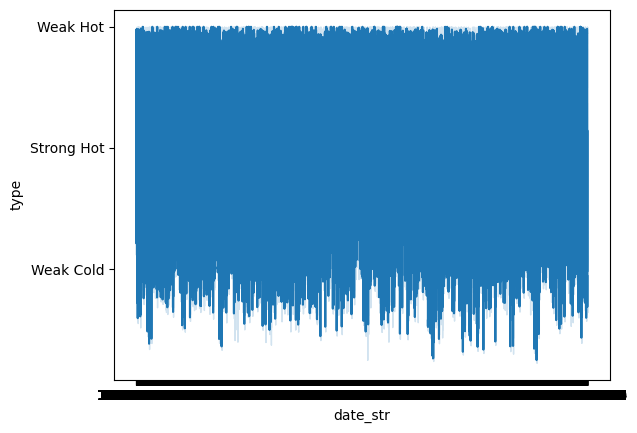

In [ ]:
sns.lineplot(x='date_str', y='type', data=df)



---


checking if there are missing values

In [ ]:
df_sample.isnull().values.any()
print(df_sample.isnull().sum())

index                0
date_str             0
degrees_from_mean    0
id                   0
longitude            0
latitude             0
max_temp             0
min_temp             0
station_name         0
type                 0
serialid             0
dtype: int64


there are no missing values.


---



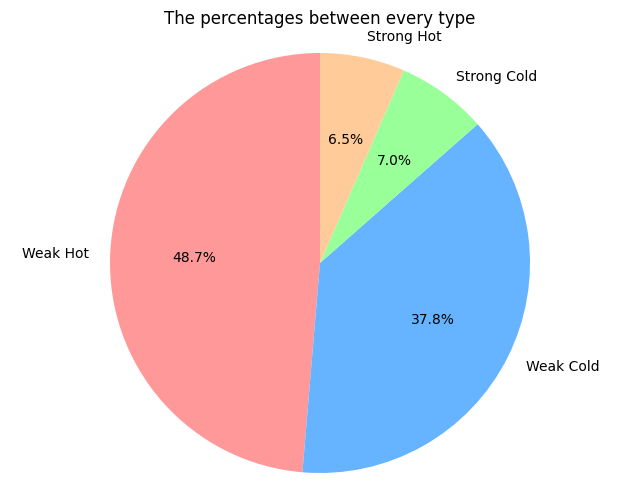

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame


sex_counts = df['type'].value_counts()

# Plotting the pie chart
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')

plt.title('The percentages between every type')
plt.show()

<Axes: xlabel='longitude', ylabel='type'>

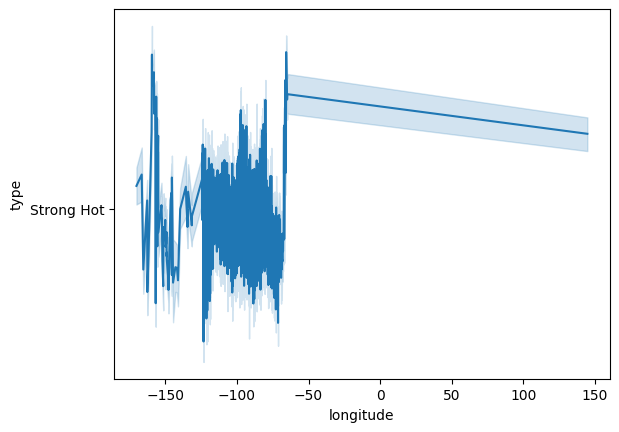

In [ ]:
sns.lineplot(x='longitude', y='type', data=df)

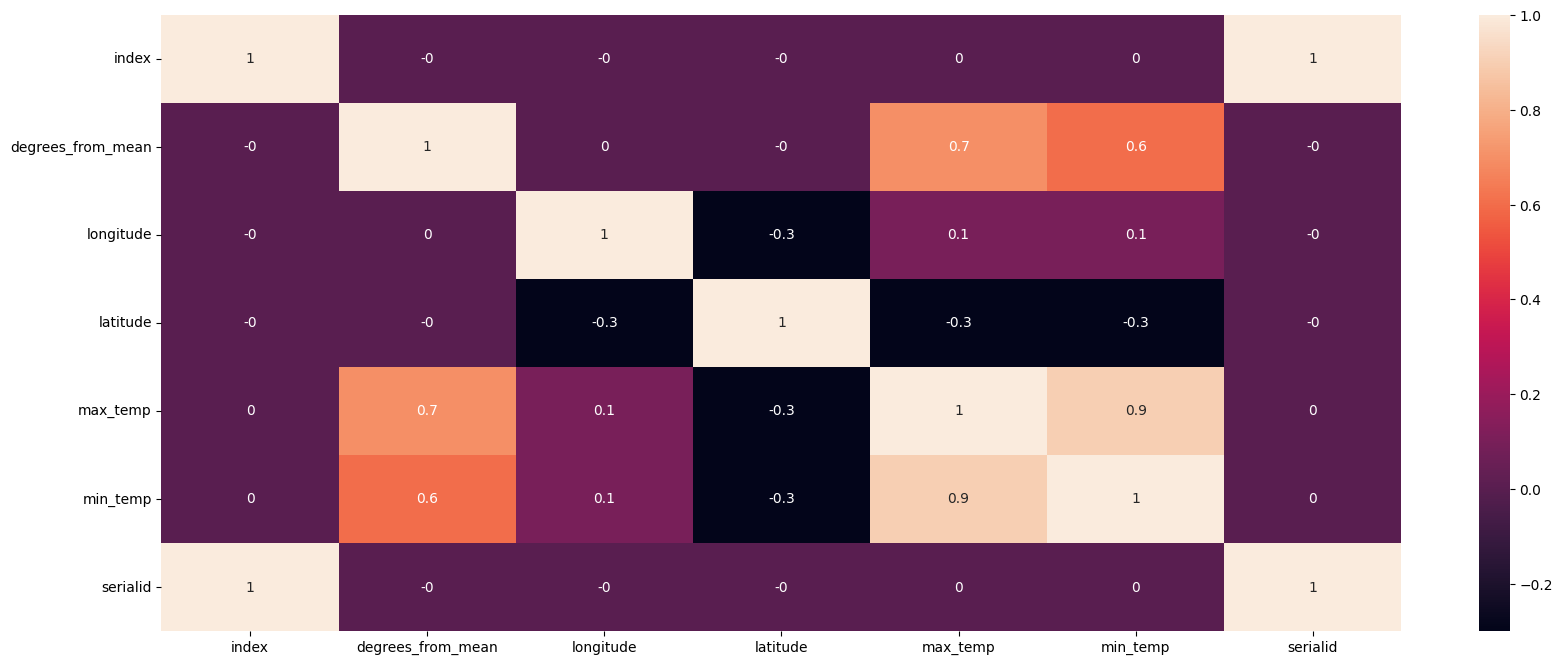

In [ ]:
corrHeatMap=df.corr(numeric_only =True).round(1)
plt.figure(figsize=(20, 8))
sns.heatmap(corrHeatMap,cmap='rocket',annot=True)
plt.show()

In [ ]:
df.groupby(["Pos"])[["height","weight"]].mean(numeric_only=True).round() #איחוד עמודות גובה ומשקל ובדיקת ממוצע מעוגל

Text(83.22222222222221, 0.5, 'degrees_from_mean')

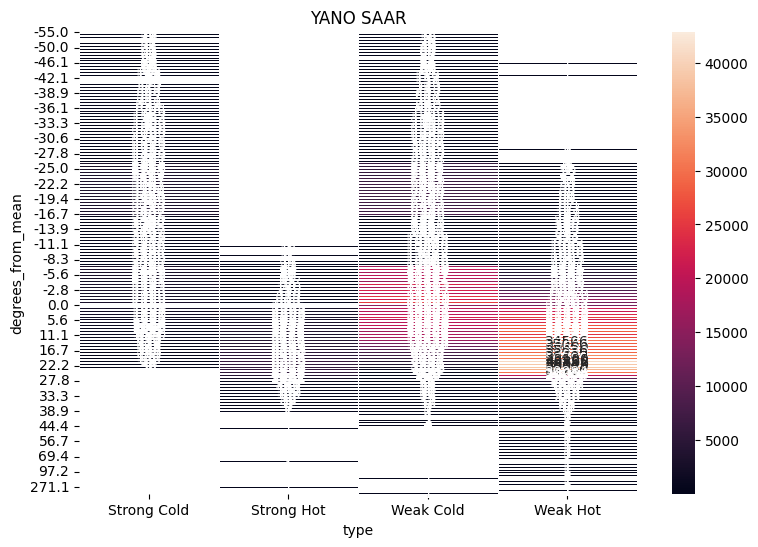

In [ ]:
heatmap_data = df.pivot_table(index='min_temp', columns='type', values='index', aggfunc='count')
f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(heatmap_data, annot=True, fmt="g", linewidths=.5, ax=ax)
plt.title('')
plt.xlabel('type')
plt.ylabel('degrees_from_mean')

KeyboardInterrupt: 

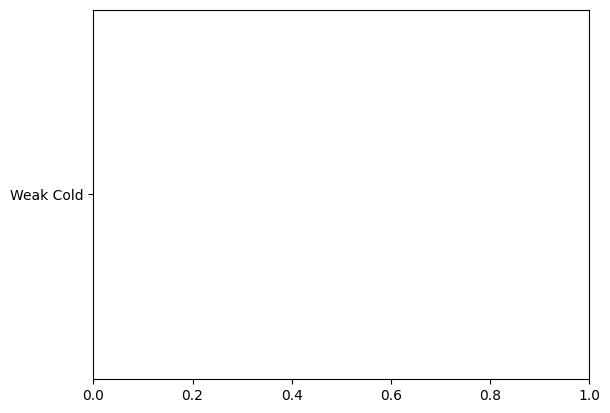

In [ ]:
sns.lineplot(x='degrees_from_mean', y='type', data=df_sample)

<ipython-input-25-5604009485ce>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df_sample, x='degrees_from_mean', y='type', inner='box', palette='Dark2')


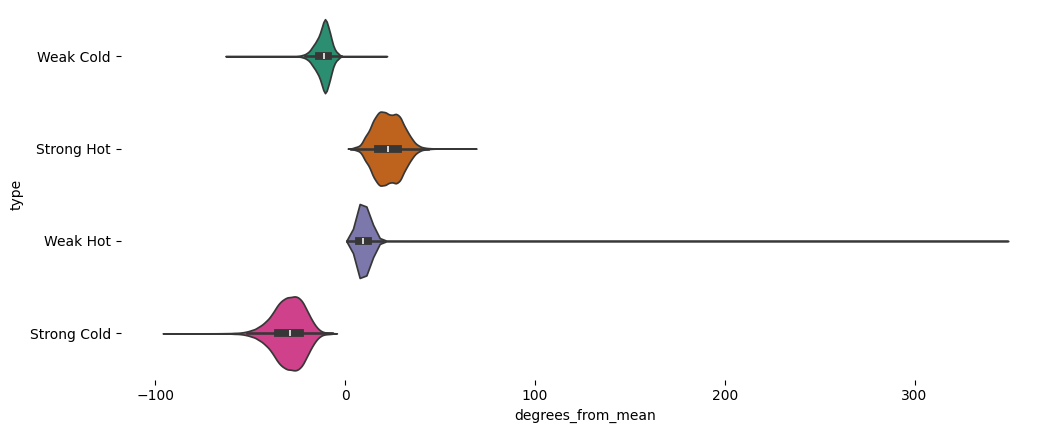

In [ ]:
# TODO
figsize = (12, 1.2 * len(df['type'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df_sample, x='degrees_from_mean', y='type', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

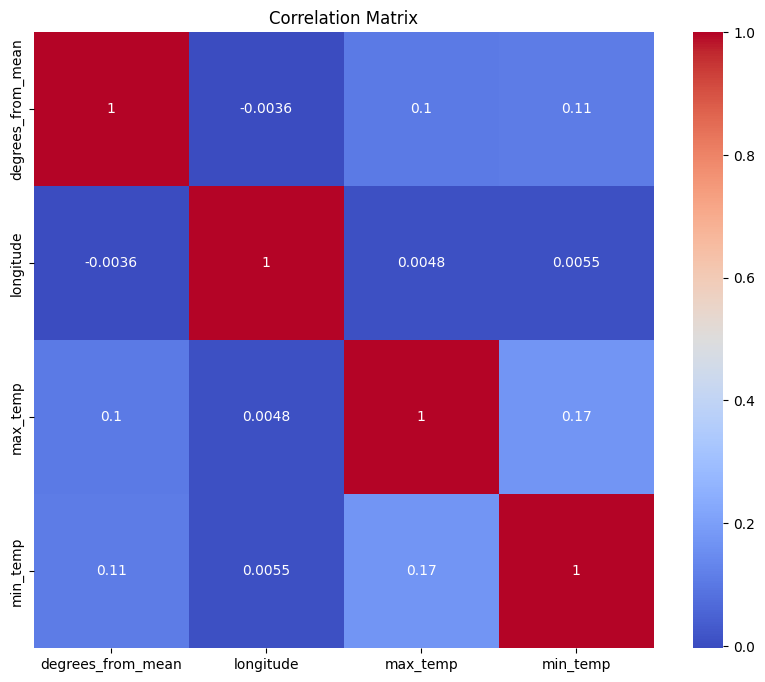

In [ ]:
# TODO
correlation = df_sample[['degrees_from_mean', 'longitude', 'max_temp', 'min_temp']].apply(lambda x: pd.factorize(x) [0]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

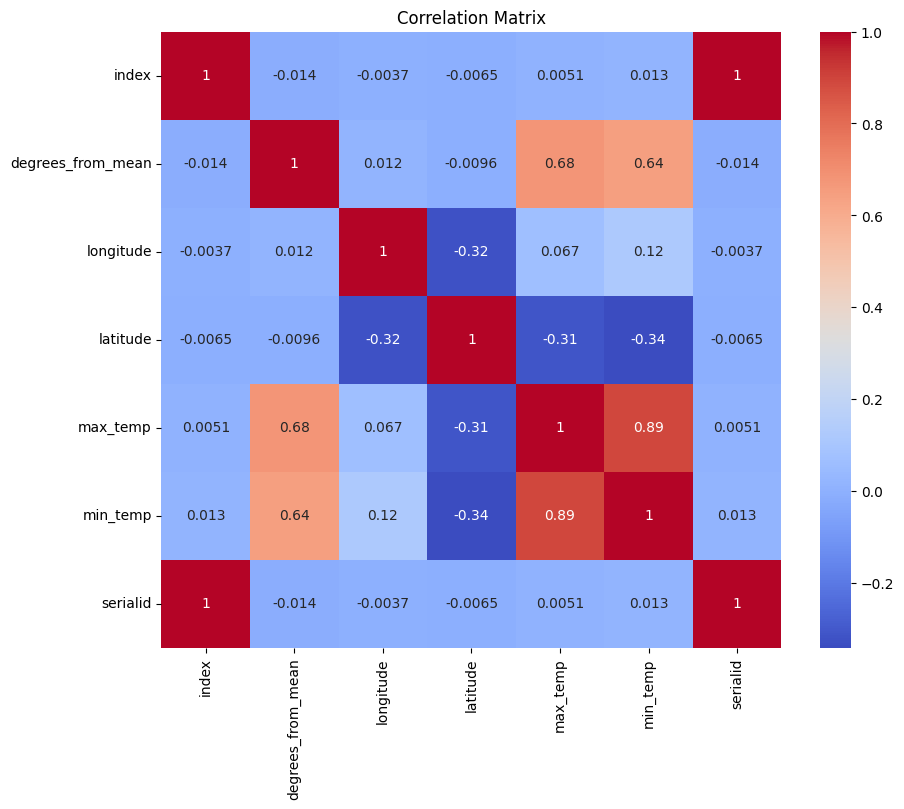

In [ ]:
# Heatmap: Correlation Matrix
# Select only numeric columns
numeric_cols = df_sample.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df_sample[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

conclusion:

The heatmap highlights that temperature variables (max_temp and min_temp) are closely related to each other, which is expected due to the nature of weather data.


---



<ipython-input-146-f808e920df8c>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='date_str', y='degrees_from_mean', data=df_sample, ci=None)


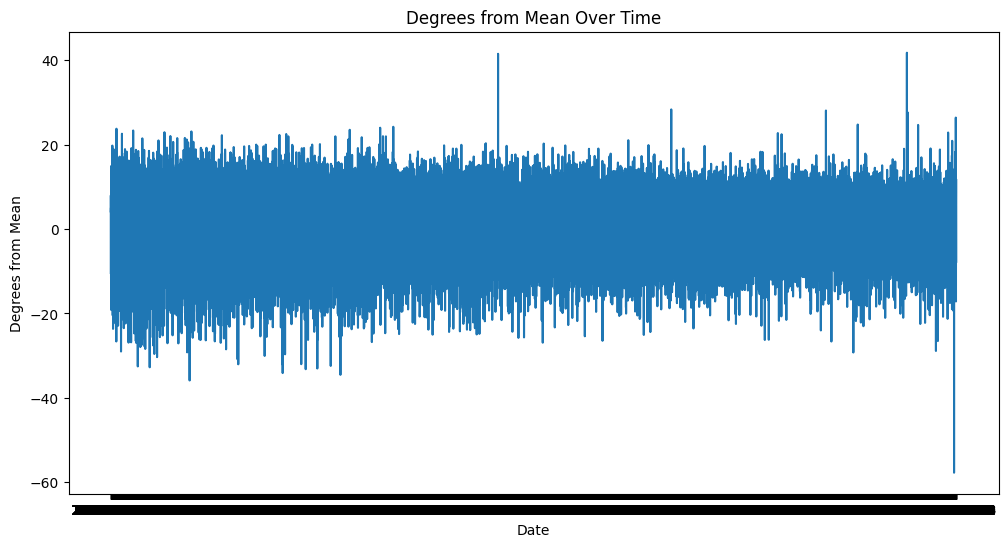

In [ ]:
# Line Plot: Degrees from Mean Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x='date_str', y='degrees_from_mean', data=df_sample, ci=None)
plt.title('Degrees from Mean Over Time')
plt.ylabel('Degrees from Mean')
plt.xlabel('Date')
plt.show()

conclusion:

The line plot reveals periodic fluctuations in temperature from the mean, suggesting seasonal influences or environmental factors at play.


---



<ipython-input-147-cdfa48d38c6d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='type', y='max_temp', data=df_sample, palette='Set2')


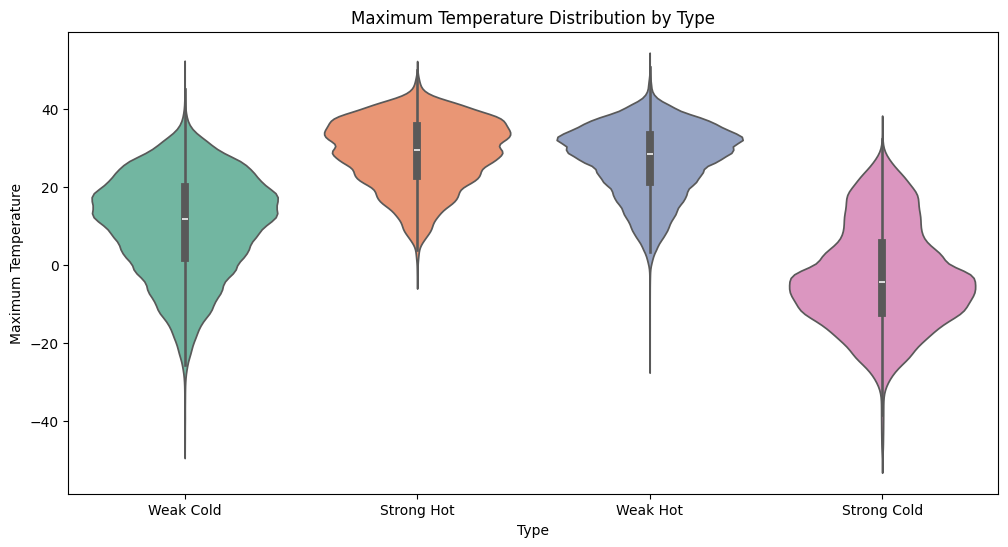

In [ ]:
# Violin Plot for Maximum Temperature Distribution by Type
plt.figure(figsize=(12, 6))
sns.violinplot(x='type', y='max_temp', data=df_sample, palette='Set2')
plt.title('Maximum Temperature Distribution by Type')
plt.ylabel('Maximum Temperature')
plt.xlabel('Type')
plt.show()

conclusion:

The violin plot illustrates the distribution of maximum temperatures across different types, highlighting the variability and density of temperature readings within each category.

---



<ipython-input-148-cced903f0b15>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='type', y='min_temp', data=df_sample, palette='Set3')


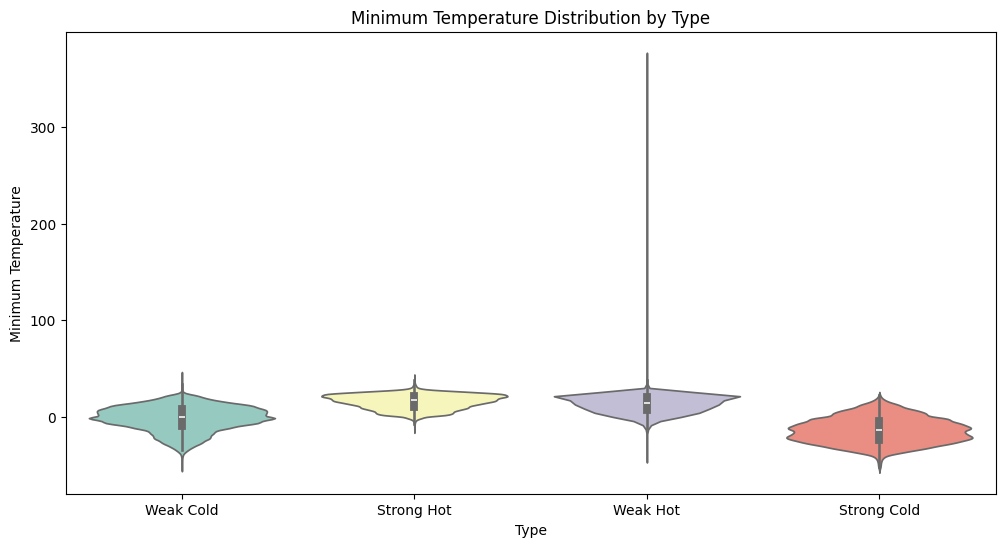

In [ ]:
# Violin Plot for Minimum Temperature Distribution by Type
plt.figure(figsize=(12, 6))
sns.violinplot(x='type', y='min_temp', data=df_sample, palette='Set3')
plt.title('Minimum Temperature Distribution by Type')
plt.ylabel('Minimum Temperature')
plt.xlabel('Type')
plt.show()

conclusion:

The violin plot for the minimum temperature distribution by type shows the range and density of minimum temperatures for each category.

---



<ipython-input-149-96ed5c6c9354>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='max_temp', data=df_sample, palette='Set2')


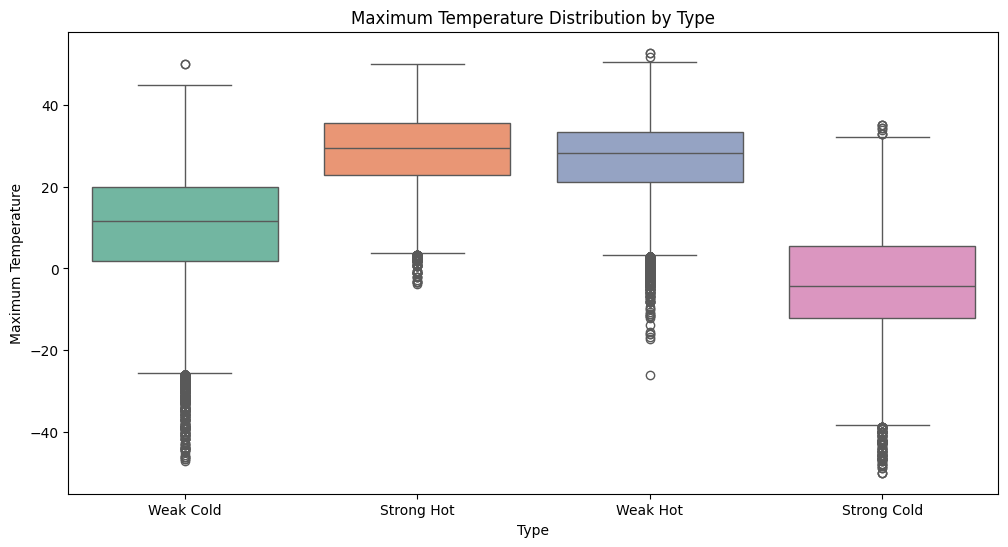

In [ ]:
# Box Plot: Temperature Distribution by Type (Max and Min)
plt.figure(figsize=(12, 6))
sns.boxplot(x='type', y='max_temp', data=df_sample, palette='Set2')
plt.title('Maximum Temperature Distribution by Type')
plt.ylabel('Maximum Temperature')
plt.xlabel('Type')
plt.show()



---



<ipython-input-150-f92c26c18523>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='min_temp', data=df_sample, palette='Set3')


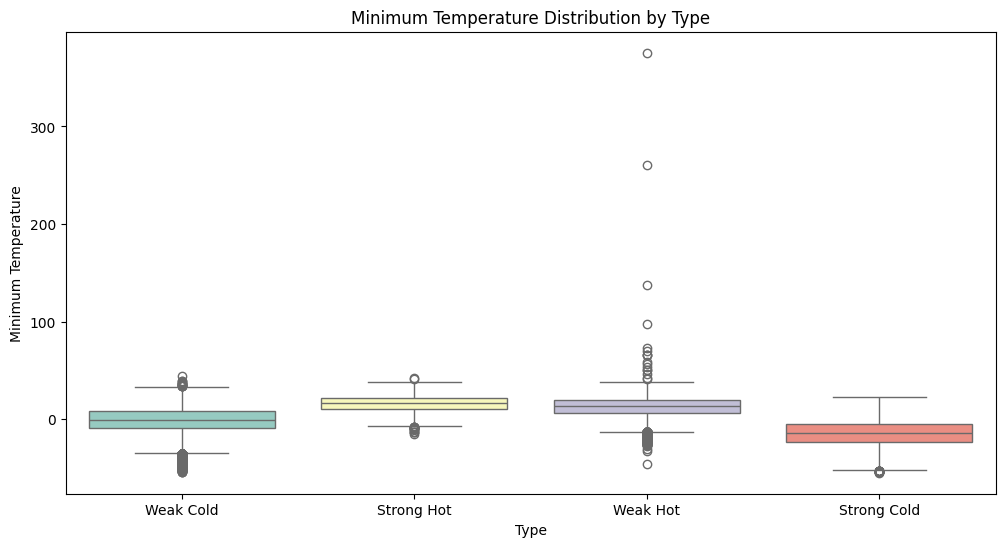

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='type', y='min_temp', data=df_sample, palette='Set3')
plt.title('Minimum Temperature Distribution by Type')
plt.ylabel('Minimum Temperature')
plt.xlabel('Type')
plt.show()



---



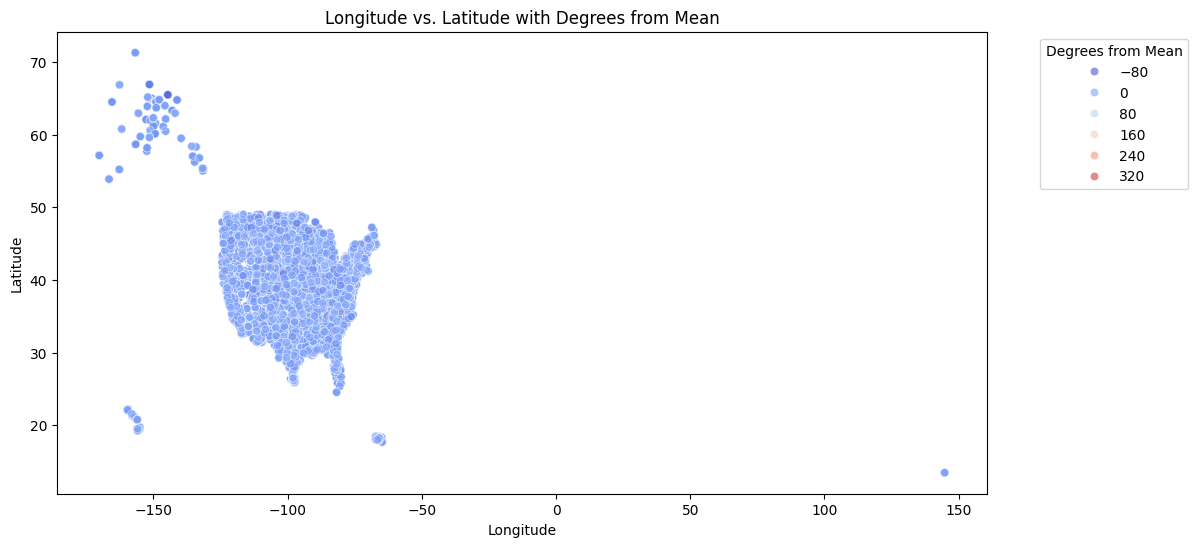

In [ ]:
# Scatter Plot: Longitude vs. Latitude with Degrees from Mean
plt.figure(figsize=(12, 6))
sns.scatterplot(x='longitude', y='latitude', hue='degrees_from_mean', palette='coolwarm', data=df_sample, alpha=0.6)
plt.title('Longitude vs. Latitude with Degrees from Mean')
plt.ylabel('Latitude')
plt.xlabel('Longitude')
plt.legend(title='Degrees from Mean', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



---



In [ ]:
df_sample

,index,date_str,degrees_from_mean,id,longitude,latitude,max_temp,min_temp,station_name,type,serialid
2299023,2299023,1996-07-11,-9.35,USW00093986,-99.0525,34.9894,26.1,18.3,HOBART MUNI AP,Weak Cold,2299024
3124038,3124038,1990-07-04,13.18,USC00131533,-95.0192,40.7244,37.8,23.9,CLARINDA,Strong Hot,3124039
1896869,1896869,1997-02-26,10.32,USC00429136,-113.6667,37.3522,21.1,0.0,VEYO PWR HOUSE,Weak Hot,1896870
2167488,2167488,1992-04-02,-15.10,USC00413329,-98.9089,30.2392,11.1,6.1,FREDERICKSBURG,Weak Cold,2167489
2775266,2775266,2010-07-19,2.43,USW00012835,-81.8614,26.5850,35.0,26.1,FT MYERS PAGE FLD AP,Weak Hot,2775267
...,...,...,...,...,...,...,...,...,...,...,...
784381,784381,1967-03-31,14.36,USC00237578,-91.2494,39.6361,25.0,14.4,SAVERTON LOCK AND DAM 22,Weak Hot,784382
282737,282737,1981-11-04,11.61,USC00106877,-113.7622,42.6283,20.0,-2.8,PAUL 1ENE,Weak Hot,282738
968243,968243,2013-09-05,10.91,USC00391294,-103.9744,45.5489,33.3,16.7,CAMP CROOK,Weak Hot,968244
2414875,2414875,1985-09-20,-12.35,USC00253630,-97.2608,42.6167,12.8,6.1,HARTINGTON,Weak Cold,2414876




---



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
X = df_sample[['longitude','latitude','max_temp','min_temp']]
y = df_sample[['type']].values.ravel()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
neigh = KNeighborsClassifier(n_neighbors=6)
neigh.fit(X_train, y_train)
y_pred = neigh.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

ValueError: could not convert string to float: '1979-01-08'

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80)

In [ ]:
X_Train, X_Test, y_train, y_test = train_test_split(X, y, test_size=0.2)
y_train = y_train.ravel() #מוחק הודעות שמפריעות לנראות של הקוד
y_test = y_test.ravel() #מוחק הודעות שמפריעות לנראות של הקוד
scaler = MinMaxScaler()
X_Train = scaler.fit_transform(X_Train)
X_Test = scaler.transform(X_Test)
max_accur = 0.0
for k in range(3, 20, 2):
    knn1 = KNeighborsClassifier(n_neighbors=k)
    knn1.fit(X_Train, y_train)
    accur = knn1.score(X_Test, y_test)
    if accur > max_accur:
        max_accur = accur
        best_k = k
    print("Accuracy for k=", k, " is ", accur, " Cross Validation value is ", np.mean(cross_val_score(knn1, X_Test, y_test, cv=5)))

Accuracy for k= 3  is  0.7181  Cross Validation value is  0.6892199999999999
Accuracy for k= 5  is  0.73058  Cross Validation value is  0.70353
Accuracy for k= 7  is  0.73545  Cross Validation value is  0.7116


KeyboardInterrupt: 

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
X = df_sample[['degrees_from_mean','longitude','latitude','max_temp','min_temp']]
y = df_sample[['type']].values.ravel()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
neigh = KNeighborsClassifier(n_neighbors=6)
neigh.fit(X_train, y_train)
y_pred = neigh.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

---------------------------------------------------------

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80)

---------------------------------------------------------

In [ ]:
X_Train, X_Test, y_train, y_test = train_test_split(X, y, test_size=0.2)
y_train = y_train.ravel() #מוחק הודעות שמפריעות לנראות של הקוד
y_test = y_test.ravel() #מוחק הודעות שמפריעות לנראות של הקוד
scaler = MinMaxScaler()
X_Train = scaler.fit_transform(X_Train)
X_Test = scaler.transform(X_Test)
max_accur = 0.0
for k in range(3, 20, 2):
    knn1 = KNeighborsClassifier(n_neighbors=k)
    knn1.fit(X_Train, y_train)
    accur = knn1.score(X_Test, y_test)
    if accur > max_accur:
        max_accur = accur
        best_k = k
    print("Accuracy for k=", k, " is ", accur, " Cross Validation value is ", np.mean(cross_val_score(knn1, X_Test, y_test, cv=5)))

Accuracy for k= 3  is  0.99567  Cross Validation value is  0.98862
Accuracy for k= 5  is  0.99489  Cross Validation value is  0.9864599999999999
Accuracy for k= 7  is  0.9943  Cross Validation value is  0.9841900000000001
Accuracy for k= 9  is  0.99351  Cross Validation value is  0.98242
Accuracy for k= 11  is  0.99269  Cross Validation value is  0.9805400000000001
Accuracy for k= 13  is  0.99216  Cross Validation value is  0.9786300000000001
Accuracy for k= 15  is  0.9916  Cross Validation value is  0.9771600000000001
Accuracy for k= 17  is  0.99127  Cross Validation value is  0.9754400000000001
Accuracy for k= 19  is  0.99088  Cross Validation value is  0.9734999999999999




---



**Activating the confusion matrix to see the prediction and the accuracy**

Accuracy for the best k - 3  is  0.99567
              precision    recall  f1-score   support

 Strong Cold     0.9957    0.9846    0.9901      7087
  Strong Hot     0.9888    0.9687    0.9787      6578
   Weak Cold     0.9971    0.9988    0.9980     38028
    Weak Hot     0.9954    0.9985    0.9970     48307

    accuracy                         0.9957    100000
   macro avg     0.9943    0.9877    0.9909    100000
weighted avg     0.9957    0.9957    0.9957    100000



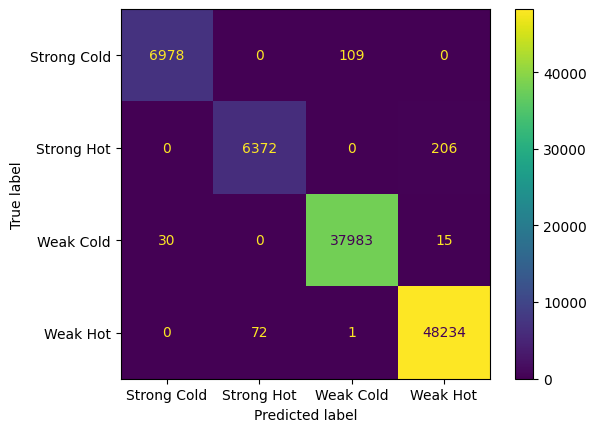

In [ ]:
knn1 = KNeighborsClassifier(n_neighbors=best_k)
knn1.fit(X_Train,y_train)
print ("Accuracy for the best k -",best_k," is ",knn1.score(X_Test,y_test))

ConfusionMatrixDisplay.from_estimator(knn1, X_Test, y_test)
pred1 = knn1.predict(X_Test)
print (classification_report(y_test,pred1,digits=4))

conclusion:

As we can see the prediction was very accurate with an accuracy of 0.9957


---



Checking the latitude of the weather station in relation to the weather level

<ipython-input-144-eecf567cf764>:1: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.6`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(df_sample, x="latitude", hue="type",bw=0.6)


<Axes: xlabel='latitude', ylabel='Density'>

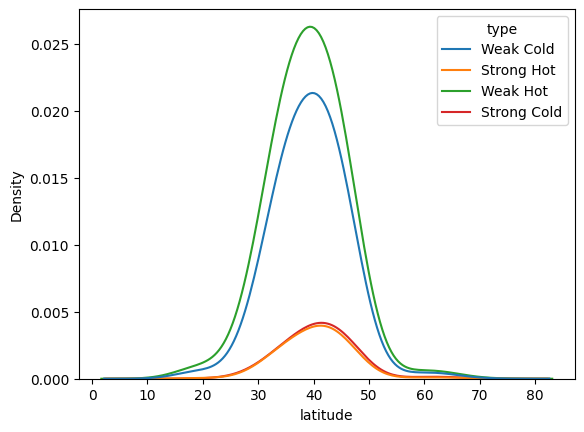

In [ ]:
sns.kdeplot(df_sample, x="latitude", hue="type",bw=0.6)

conclusion:

we can see Weak Hot is similar to Weak cold and Strong cold and Strong Hot are very similar to each other.


---



<ipython-input-143-c119c4fd005a>:1: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.6`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(df_sample, x="degrees_from_mean", hue="type",bw=0.6)


<Axes: xlabel='degrees_from_mean', ylabel='Density'>

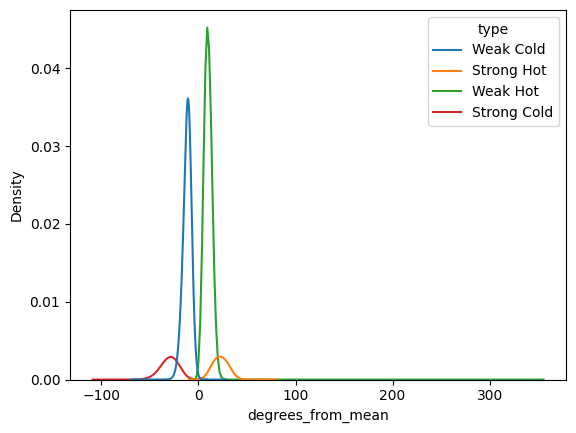

In [ ]:
sns.kdeplot(df_sample, x="degrees_from_mean", hue="type",bw=0.6)

conclusion:

we can see Weak Hot is similar to Weak cold and Strong cold and Strong Hot are very similar to each other.

just the same as "degrees_from_mean".


---



<ipython-input-141-475a7886de8c>:1: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.6`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(df_sample, x="min_temp", hue="type",bw=0.6)


<Axes: xlabel='min_temp', ylabel='Density'>

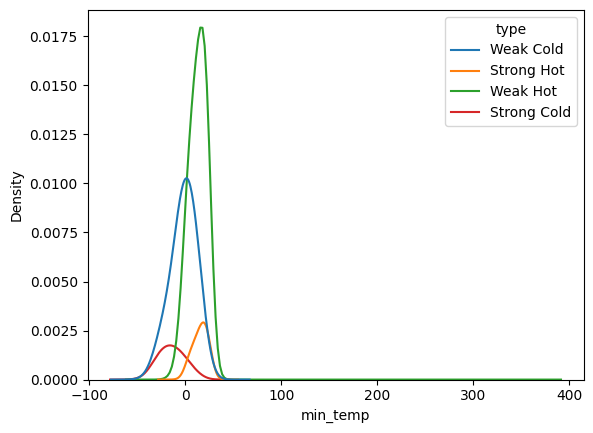

In [ ]:
sns.kdeplot(df_sample, x="min_temp", hue="type",bw=0.6)

conclusion:

we can see that Weak Hot and Weak cold have gain more Density than Strong cold and Strong Hot.


---



<ipython-input-142-791fb4a5da3d>:1: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.6`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  sns.kdeplot(df_sample, x="max_temp", hue="type",bw=0.6)


<Axes: xlabel='max_temp', ylabel='Density'>

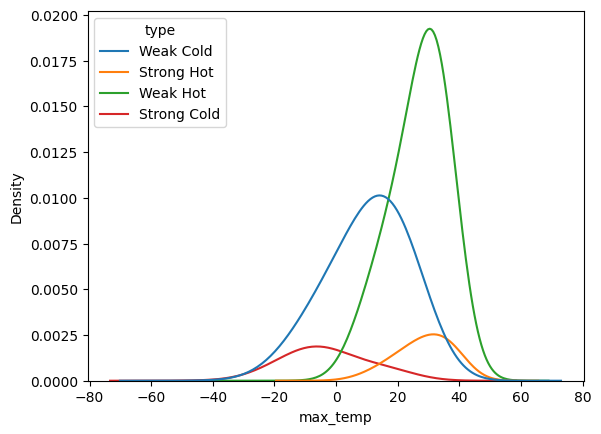

In [ ]:
sns.kdeplot(df_sample, x="max_temp", hue="type",bw=0.6)

conclusion:

we can see that Weak Hot and Weak cold have gain more Density than Strong cold and Strong Hot.

same as "min_temp".


---



In [ ]:
X = svm_df
y = svm_df

X=X.drop(['type'],axis=1).to_numpy()
y=y['type'].to_numpy()
X_Train,X_Test,y_train,y_test = train_test_split(X,y,test_size=0.3)
scaler=MinMaxScaler()
X_Train=scaler.fit_transform(X_Train)
X_Test=scaler.transform(X_Test)

NameError: name 'svm_df' is not defined

In [ ]:
max_c=0
best_score=0
for c in range(10,100,10):
    svm=SVC(kernel='rbf',C=c)
    svm.fit(X_Train,y_train)
    score = svm.score(X_Test, y_test)
    if (score>best_score):
      max_c=c
      best_score=score
print("max_c = {} score test: {}".format(max_c,best_score))

max_c = 90 score test: 0.99242


              precision    recall  f1-score   support

 Strong Cold     0.9754    0.9498    0.9624      7087
  Strong Hot     0.9574    0.9024    0.9291      6578
   Weak Cold     0.9907    0.9946    0.9926     38028
    Weak Hot     0.9861    0.9945    0.9903     48307

    accuracy                         0.9853    100000
   macro avg     0.9774    0.9603    0.9686    100000
weighted avg     0.9852    0.9853    0.9852    100000



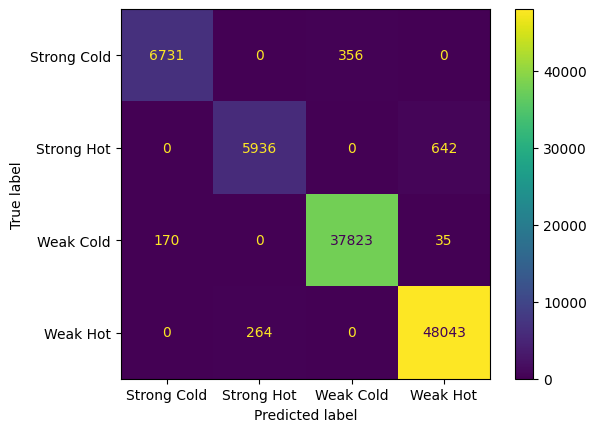

In [ ]:
svm1 = SVC(kernel='rbf',C=best_score)
svm1.fit(X_Train,y_train)
ConfusionMatrixDisplay.from_estimator(svm1, X_Test, y_test)
pred1 = svm1.predict(X_Test)
print (classification_report(y_test,pred1,digits=4))

In [ ]:
max_c=0
best_score=0
for c in range(10,100,10):
    svm=SVC(kernel='linear',C=c)
    svm.fit(X_Train,y_train)
    score = svm.score(X_Test, y_test)
    if (score>best_score):
      max_c=c
      best_score=score
print("max_c = {} score test: {}".format(max_c,best_score))

max_c = 80 score test: 0.97904


              precision    recall  f1-score   support

 Strong Cold     0.9737    0.9128    0.9423      7100
  Strong Hot     0.9602    0.7998    0.8727      6552
   Weak Cold     0.9838    0.9943    0.9890     37824
    Weak Hot     0.9728    0.9955    0.9840     48524

    accuracy                         0.9764    100000
   macro avg     0.9726    0.9256    0.9470    100000
weighted avg     0.9762    0.9764    0.9756    100000



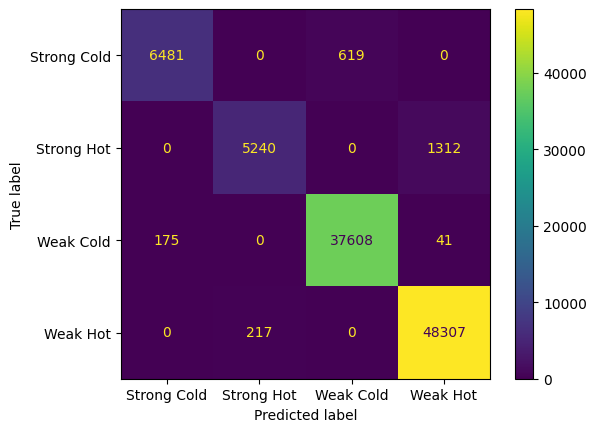

In [ ]:
svm1 = SVC(kernel='linear',C=best_score)
svm1.fit(X_Train,y_train)
ConfusionMatrixDisplay.from_estimator(svm1, X_Test, y_test)
pred1 = svm1.predict(X_Test)
print (classification_report(y_test,pred1,digits=4))

score is: 0.99648, c is: 10
score is: 0.99669, c is: 20
score is: 0.9968, c is: 30
score is: 0.99688, c is: 40
score is: 0.99698, c is: 50
score is: 0.99699, c is: 60
score is: 0.99699, c is: 70
score is: 0.99703, c is: 80
score is: 0.99706, c is: 90
score is: 0.99018, c is: 10
score is: 0.99111, c is: 20
score is: 0.99167, c is: 30
score is: 0.9919, c is: 40
score is: 0.99214, c is: 50
score is: 0.99244, c is: 60
score is: 0.99257, c is: 70
score is: 0.99279, c is: 80
score is: 0.99286, c is: 90
score is: 0.98055, c is: 10
score is: 0.98177, c is: 20
score is: 0.98257, c is: 30
score is: 0.98298, c is: 40
score is: 0.98321, c is: 50
score is: 0.98335, c is: 60
score is: 0.98357, c is: 70
score is: 0.98364, c is: 80
score is: 0.98382, c is: 90
max_c = 90 score test: 0.99706
0.9921175
              precision    recall  f1-score   support

 Strong Cold     0.9918    0.9771    0.9844      6974
  Strong Hot     0.9802    0.9418    0.9606      6512
   Weak Cold     0.9958    0.9983    0.997

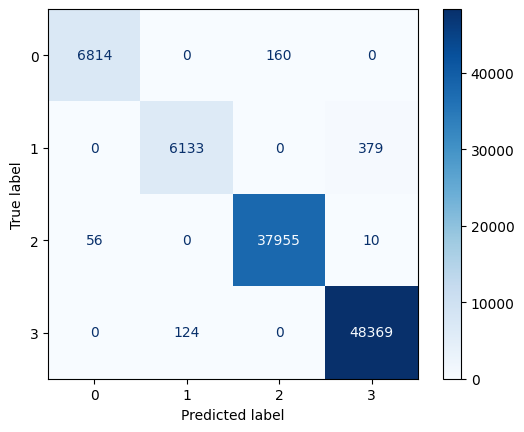

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

class svm():
    def model_training(self, X_train, X_test, y_train, y_test):
        max_c = 0
        best_score = 0
        best_scaler = None

        for scaler in [StandardScaler(), MinMaxScaler(), Normalizer()]:
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            for c in range(10, 100, 10):
                svm_model = SVC(kernel='rbf', C=c)
                svm_model.fit(X_train_scaled, y_train)
                score = svm_model.score(X_test_scaled, y_test)
                print(f"score is: {score}, c is: {c}")
                if score > best_score:
                    max_c = c
                    best_score = score
                    best_scaler = scaler.__class__.__name__

        print(f"max_c = {max_c} score test: {best_score}")
        return max_c, best_scaler, best_score

    def evaluate(self, X_train, X_test, y_train, y_test, max_c, best_scaler):
        scaler = None
        if best_scaler == 'StandardScaler':
            scaler = StandardScaler()
        elif best_scaler == 'MinMaxScaler':
            scaler = MinMaxScaler()
        elif best_scaler == 'Normalizer':
            scaler = Normalizer()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        svm_model = SVC(kernel='poly', C=max_c)
        svm_model.fit(X_train_scaled, y_train)
        cv_score = sum(cross_val_score(svm_model, X_train_scaled, y_train, cv=5)) / 5
        print(cv_score)
        return svm_model

    def ConfusionMatrix(self, X_train, X_test, y_train, y_test, svm_model, best_scaler):
        scaler = None
        if best_scaler == 'StandardScaler':
            scaler = StandardScaler()
        elif best_scaler == 'MinMaxScaler':
            scaler = MinMaxScaler()
        elif best_scaler == 'Normalizer':
            scaler = Normalizer()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        pred = svm_model.predict(X_test_scaled)
        cm = confusion_matrix(y_test, pred)
        cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
        cmd.plot(values_format="d", cmap='Blues')
        print(classification_report(y_test, pred, digits=4))
        print('### legend:\ntrue:1\nfalse:0')

# Create an instance of the svm class
svm_instance = svm()

# Assuming X_train, X_test, y_train, y_test are defined elsewhere
max_c, best_scaler, best_score = svm_instance.model_training(X_train, X_test, y_train, y_test)
svm_model = svm_instance.evaluate(X_train, X_test, y_train, y_test, max_c, best_scaler)
svm_instance.ConfusionMatrix(X_train, X_test, y_train, y_test, svm_model, best_scaler)


R^2 Score for Training Set: 1.0
R^2 Score for Testing Set: 1.0


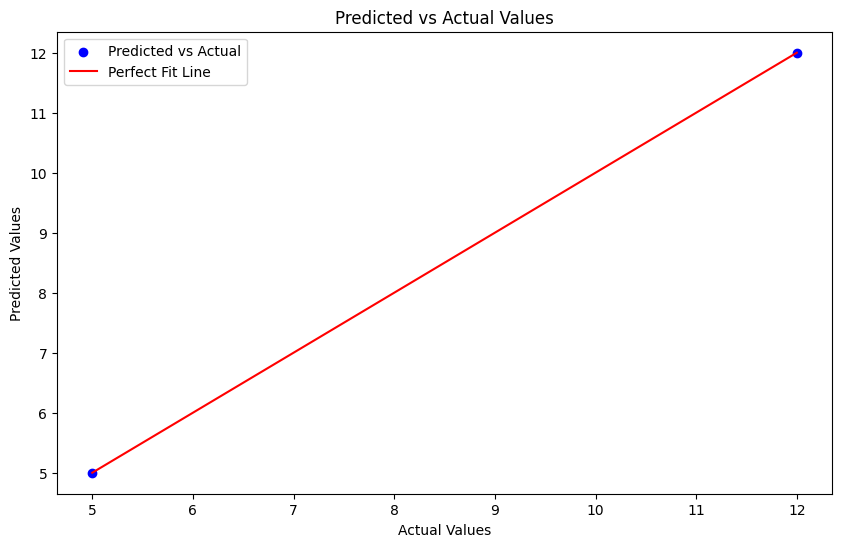

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.DataFrame(data)

# Features and target variable
X = df[['degrees_from_mean','longitude','latitude','max_temp','min_temp']]
y = df['type']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate the R^2 score for training and testing sets
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"R^2 Score for Training Set: {r2_train}")
print(f"R^2 Score for Testing Set: {r2_test}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.legend()
plt.show()

R^2 Score for Training Set (Polynomial Features): 1.0
R^2 Score for Testing Set (Polynomial Features): 1.0
Fitting 5 folds for each of 648 candidates, totalling 3240 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan 

R^2 Score for Training Set (Random Forest with Grid Search): 0.973
R^2 Score for Testing Set (Random Forest with Grid Search): 0.980930612244898


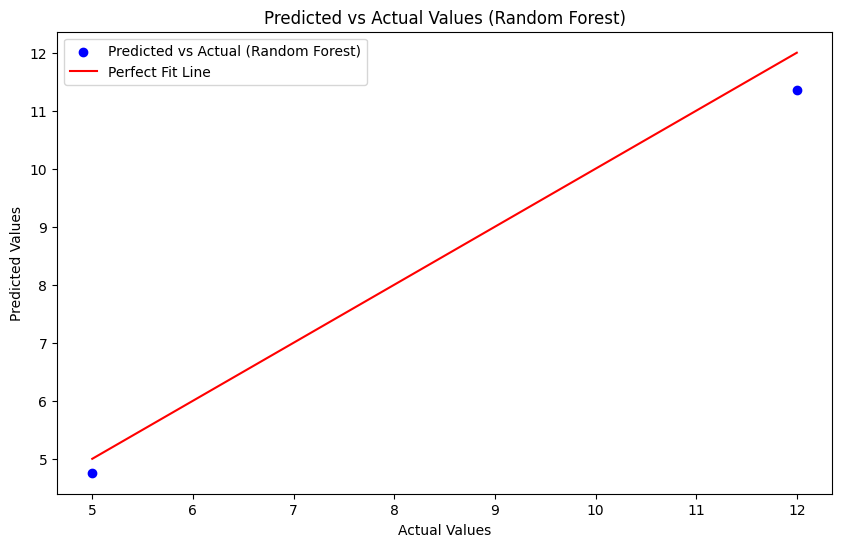

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Sample dataset
data = {
    'degrees_from_mean': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'longitude': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    'latitude': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    'max_temp': [10, 12, 14, 16, 18, 20, 22, 24, 26, 28],
    'min_temp': [5, 7, 9, 11, 13, 15, 17, 19, 21, 23],
    'type': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
}

df = pd.DataFrame(data)

# Features and target variable
X = df[['degrees_from_mean', 'longitude', 'latitude', 'max_temp', 'min_temp']]
y = df['type']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Polynomial Features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Linear Regression with Polynomial Features
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predictions and R^2 Score
y_pred_train = model.predict(X_train_poly)
y_pred_test = model.predict(X_test_poly)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"R^2 Score for Training Set (Polynomial Features): {r2_train}")
print(f"R^2 Score for Testing Set (Polynomial Features): {r2_test}")

# Random Forest with Hyperparameter Tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

# Predictions and R^2 Score for the best Random Forest model
y_pred_train_rf = best_rf.predict(X_train)
y_pred_test_rf = best_rf.predict(X_test)

r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)

print(f"R^2 Score for Training Set (Random Forest with Grid Search): {r2_train_rf}")
print(f"R^2 Score for Testing Set (Random Forest with Grid Search): {r2_test_rf}")

# Plotting the results for the best Random Forest model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test_rf, color='blue', label='Predicted vs Actual (Random Forest)')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', label='Perfect Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values (Random Forest)')
plt.legend()
plt.show()


In [ ]:
X = grouped_df
y = grouped_df
#
# using all the data takes too much time
#




y=y['type'].to_numpy()
X=X.drop(['longitude','latitude','degrees_from_mean','max_temp','min_temp'],axis=1).to_numpy()
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)


# new cell


In [ ]:
svm=SVC(kernel='poly',C=max_c)
svm.fit(X_train,y_train)
print(sum(cross_val_score(svm,X,y,cv=5))/5)

In [ ]:
pred = svm.predict(X_train)
cm = confusion_matrix(y_train, pred)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
cmd.plot(values_format="d", cmap='Blues')
print(classification_report(y_train, pred, digits=4))
md(f'### legend:'+'\n'+ 'true:1'+'\n'+'fasle:0')